Environment Set-Up

In [ ]:
# No longer needed - data loads from GitHub

#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

In [3]:
# Accessibility - to be applied to all plots
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colorblind safe palette
# Use Wong Color Blind Pallet Hex Codes
sns.set_palette("colorblind")

print("Libraries loaded and styling applied successfully")


Libraries loaded and styling applied successfully


Loading the Dataset

In [4]:
# Original datasource -  Install the UCI ML repository package
!pip install ucimlrepo #UCI package

from ucimlrepo import fetch_ucirepo

# Fetch official UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

# Separate features and target
X = heart_disease.data.features
y = heart_disease.data.targets

# Combine into single dataframe
UCI = pd.concat([X, y], axis=1)

# Check
print("Dataset Shape:", UCI.shape)
print("\nColumn Names:")
print(UCI.columns.tolist())
print("\nFirst 5 Rows:")
UCI.head()


Dataset Shape: (303, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

First 5 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


Data Inspection

In [5]:
# Check original num values
print("Original num value counts:")
print(UCI['num'].value_counts().sort_index())

# Convert to binary: 0 = no disease, 1 = disease present
UCI['target'] = (UCI['num'] > 0).astype(int)

# Drop original num column
UCI = UCI.drop(columns=['num'])

# Verify conversion
print("\nConverted target value counts:")
print(UCI['target'].value_counts())

print("\nTarget proportions:")
print(UCI['target'].value_counts(normalize=True).round(3))

print("\nNew column list:")
print(UCI.columns.tolist())

Original num value counts:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Converted target value counts:
target
0    164
1    139
Name: count, dtype: int64

Target proportions:
target
0    0.541
1    0.459
Name: proportion, dtype: float64

New column list:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [6]:
# Check for missing values
print("Data Types:")
print(UCI.dtypes)

print("\nMissing Values Per Column:")
print(UCI.isnull().sum())

print("\nTotal missing values:", UCI.isnull().sum().sum())

print("\nPercentage missing per column:")
print((UCI.isnull().sum() / len(UCI) * 100).round(2))

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object

Missing Values Per Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values: 6

Percentage missing per column:
age         0.00
sex         0.00
cp          0.00
trestbps    0.00
chol        0.00
fbs         0.00
restecg     0.00
thalach     0.00
exang       0.00
oldpeak     0.00
slope       0.00
ca          1.32
thal        0.66
target      0.00
dtype: float64


In [7]:
# Uniqueness for Categorical Variables

#Create lists for unique values
categorical = ['sex', 'cp', 'fbs', 'restecg', 'exang',
               'slope', 'ca', 'thal', 'target']

continuous = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in categorical: # loop through each column in categorical list for unique value counts
    print(f"{col}: {sorted(UCI[col].dropna().unique())} " # sort values and drop NA for inspection
          f"({UCI[col].nunique()} unique values) "
          f"| Missing: {UCI[col].isnull().sum()}")

sex: [np.int64(0), np.int64(1)] (2 unique values) | Missing: 0
cp: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)] (4 unique values) | Missing: 0
fbs: [np.int64(0), np.int64(1)] (2 unique values) | Missing: 0
restecg: [np.int64(0), np.int64(1), np.int64(2)] (3 unique values) | Missing: 0
exang: [np.int64(0), np.int64(1)] (2 unique values) | Missing: 0
slope: [np.int64(1), np.int64(2), np.int64(3)] (3 unique values) | Missing: 0
ca: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)] (4 unique values) | Missing: 4
thal: [np.float64(3.0), np.float64(6.0), np.float64(7.0)] (3 unique values) | Missing: 2
target: [np.int64(0), np.int64(1)] (2 unique values) | Missing: 0


In [8]:
# Descriptive Statistics for Continuous Variables

cont_stats = UCI[continuous].describe().T # calculate count, mean, median, SD, min, max, quartiles

# Add skewness and kurtosis columns
cont_stats['skewness'] = UCI[continuous].skew() # positive = right tail # negative = left tail
cont_stats['kurtosis'] = UCI[continuous].kurt() # positive = extreme outliers # negative = less outliers

print("Descriptive Statistics - Continuous Variables:")
print(cont_stats.round(2))

Descriptive Statistics - Continuous Variables:
          count    mean    std    min    25%    50%    75%    max  skewness  \
age       303.0   54.44   9.04   29.0   48.0   56.0   61.0   77.0     -0.21   
trestbps  303.0  131.69  17.60   94.0  120.0  130.0  140.0  200.0      0.71   
chol      303.0  246.69  51.78  126.0  211.0  241.0  275.0  564.0      1.14   
thalach   303.0  149.61  22.88   71.0  133.5  153.0  166.0  202.0     -0.54   
oldpeak   303.0    1.04   1.16    0.0    0.0    0.8    1.6    6.2      1.27   

          kurtosis  
age          -0.52  
trestbps      0.88  
chol          4.49  
thalach      -0.05  
oldpeak       1.58  


In [9]:
print("Descriptive Statistics - Categorical Variables:\n")

for col in categorical:
    print(f" {col} ")
    counts = UCI[col].value_counts(dropna=False) # don't drop NA so they are represented
    proportions = UCI[col].value_counts(dropna=False, normalize=True).round(3)
    summary = pd.DataFrame({
        'Count': counts,
        'Proportion': proportions
    })
    print(summary)
    print()

Descriptive Statistics - Categorical Variables:

 sex 
     Count  Proportion
sex                   
1      206        0.68
0       97        0.32

 cp 
    Count  Proportion
cp                   
4     144       0.475
3      86       0.284
2      50       0.165
1      23       0.076

 fbs 
     Count  Proportion
fbs                   
0      258       0.851
1       45       0.149

 restecg 
         Count  Proportion
restecg                   
0          151       0.498
2          148       0.488
1            4       0.013

 exang 
       Count  Proportion
exang                   
0        204       0.673
1         99       0.327

 slope 
       Count  Proportion
slope                   
1        142       0.469
2        140       0.462
3         21       0.069

 ca 
     Count  Proportion
ca                    
0.0    176       0.581
1.0     65       0.215
2.0     38       0.125
3.0     20       0.066
NaN      4       0.013

 thal 
      Count  Proportion
thal                   
3.0 

Distribution Plots

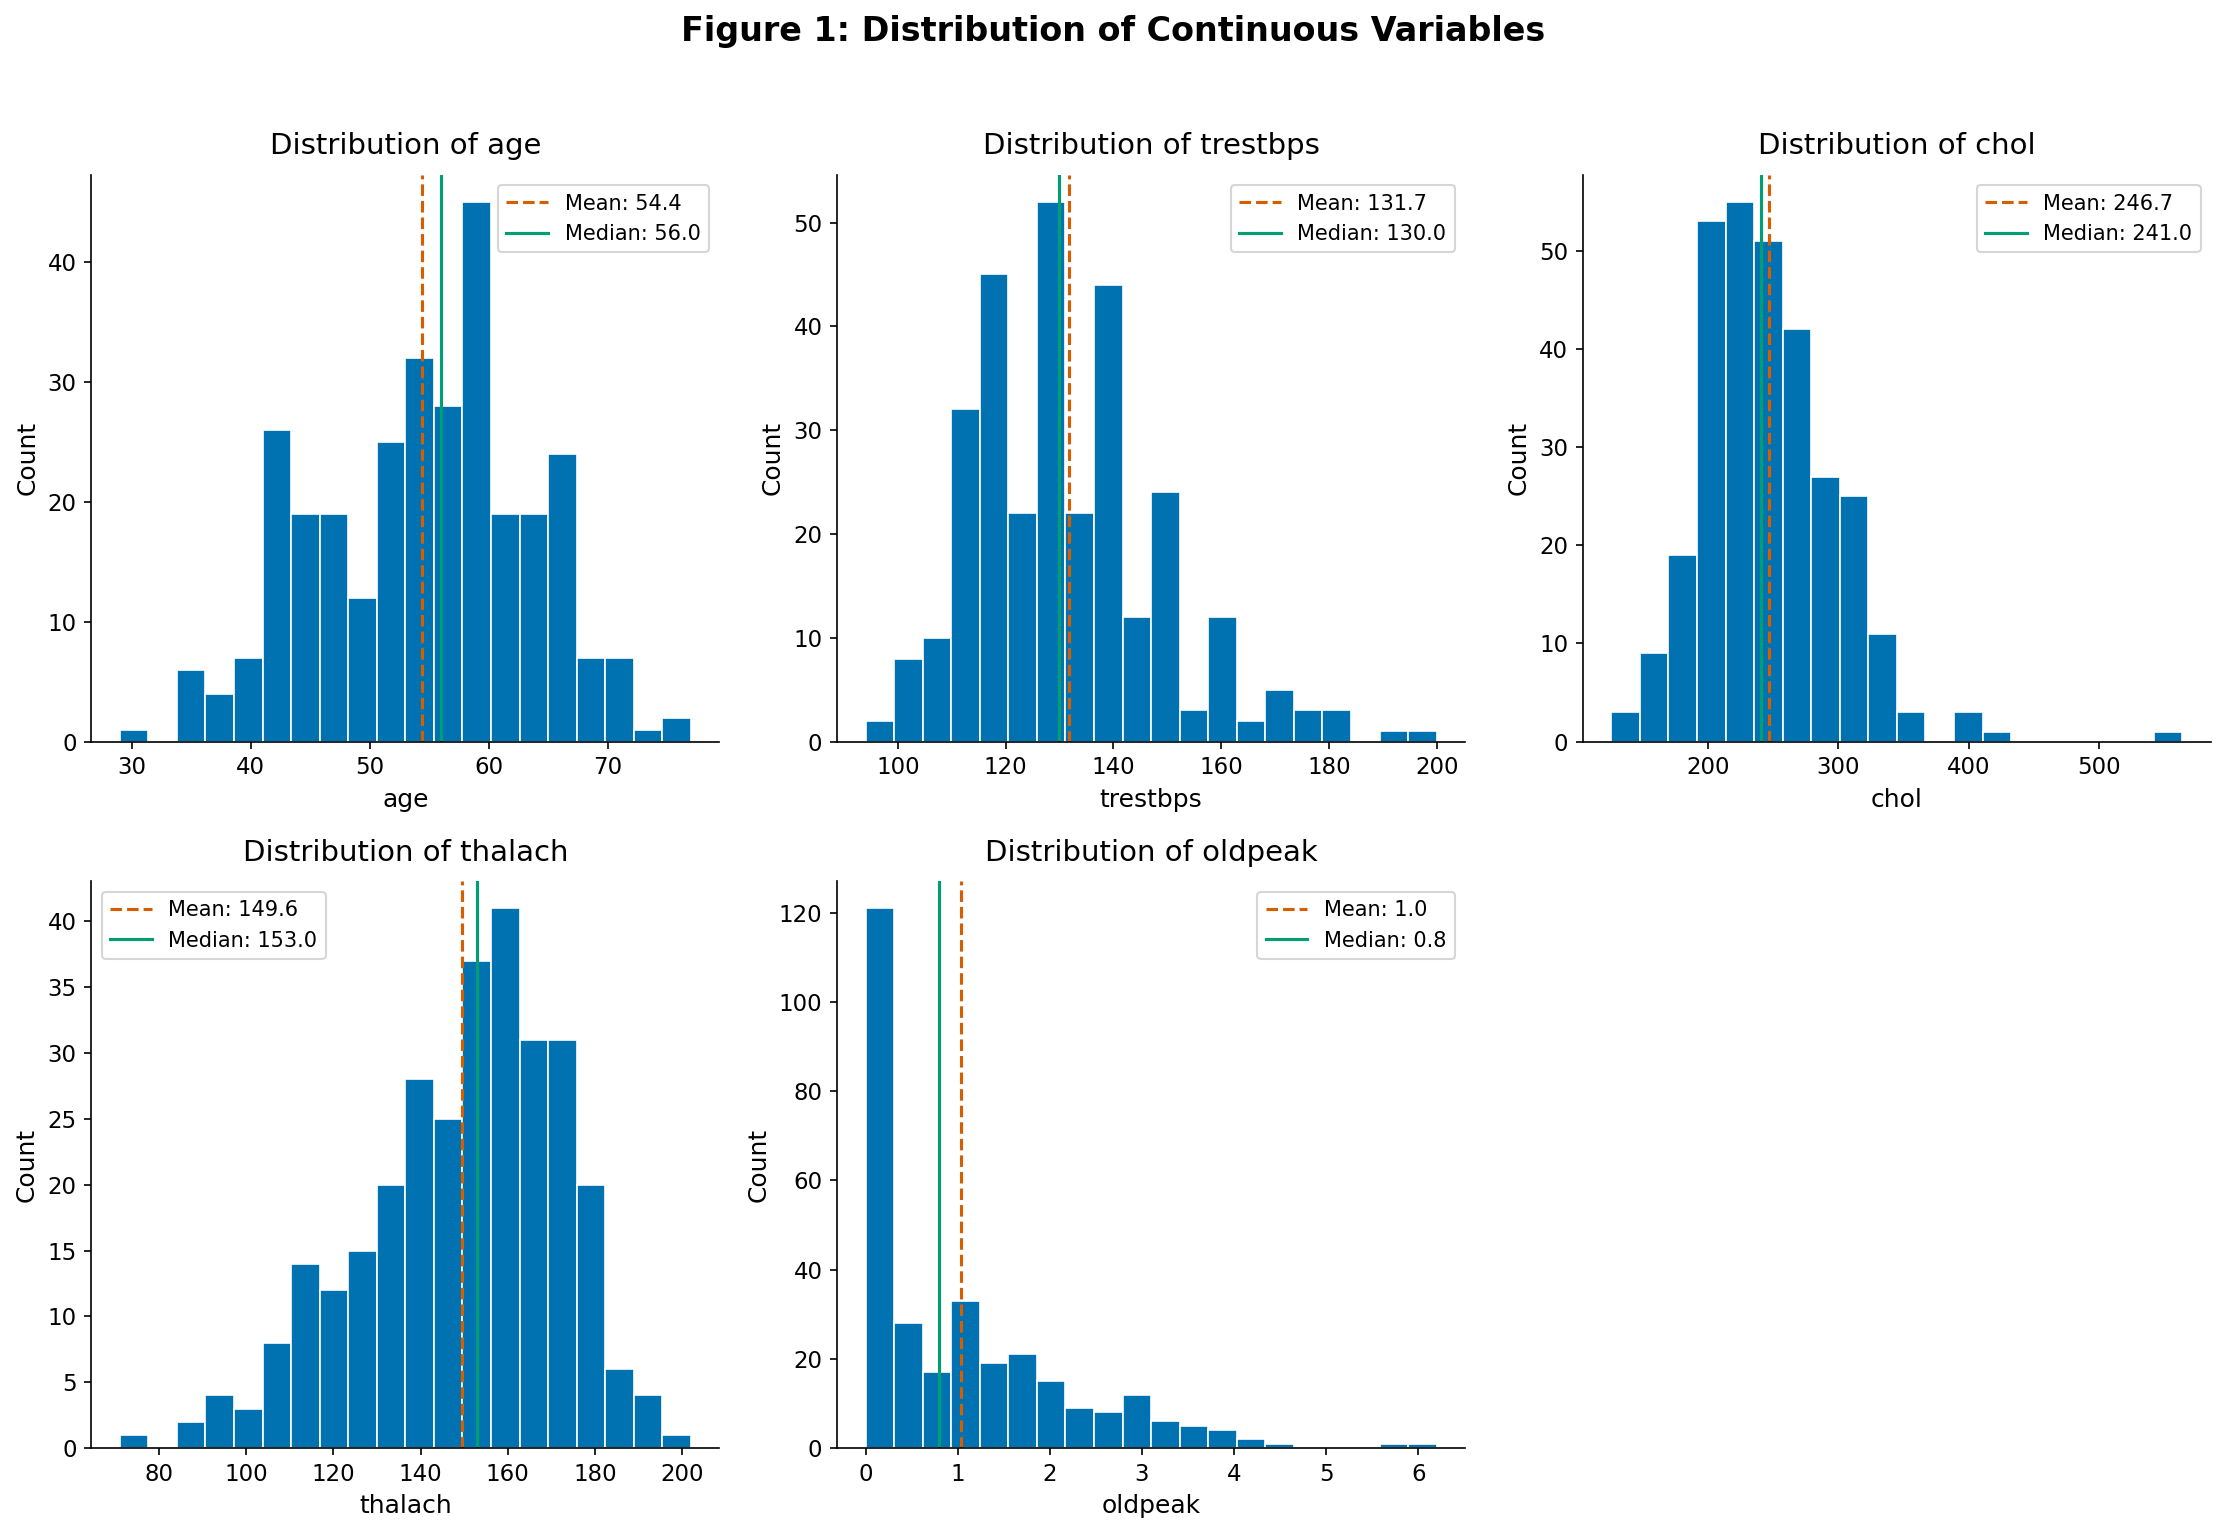

Figure 1 saved


In [10]:
# Plots for Continuous Variables

fig, axes = plt.subplots(2, 3, figsize=(15, 10)) # grid of 6 plots, 2 rows, 3 columns
axes = axes.flatten() # simpler loop thorugh each plot

for i, col in enumerate(continuous):
    axes[i].hist(UCI[col].dropna(), bins=20,
                 color='#0072B2', edgecolor='white',
                 linewidth=0.8)
    axes[i].set_title(f'Distribution of {col}',
                      fontsize=14, pad=10)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)

    # Add mean and median lines
    mean_val = UCI[col].mean()
    median_val = UCI[col].median()
    axes[i].axvline(mean_val, color='#D55E00',
                    linestyle='--', linewidth=1.5,
                    label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='#009E73',
                    linestyle='-', linewidth=1.5,
                    label=f'Median: {median_val:.1f}')
    axes[i].legend(fontsize=10)

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Figure 1: Distribution of Continuous Variables',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure1_distributions.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 1 saved")

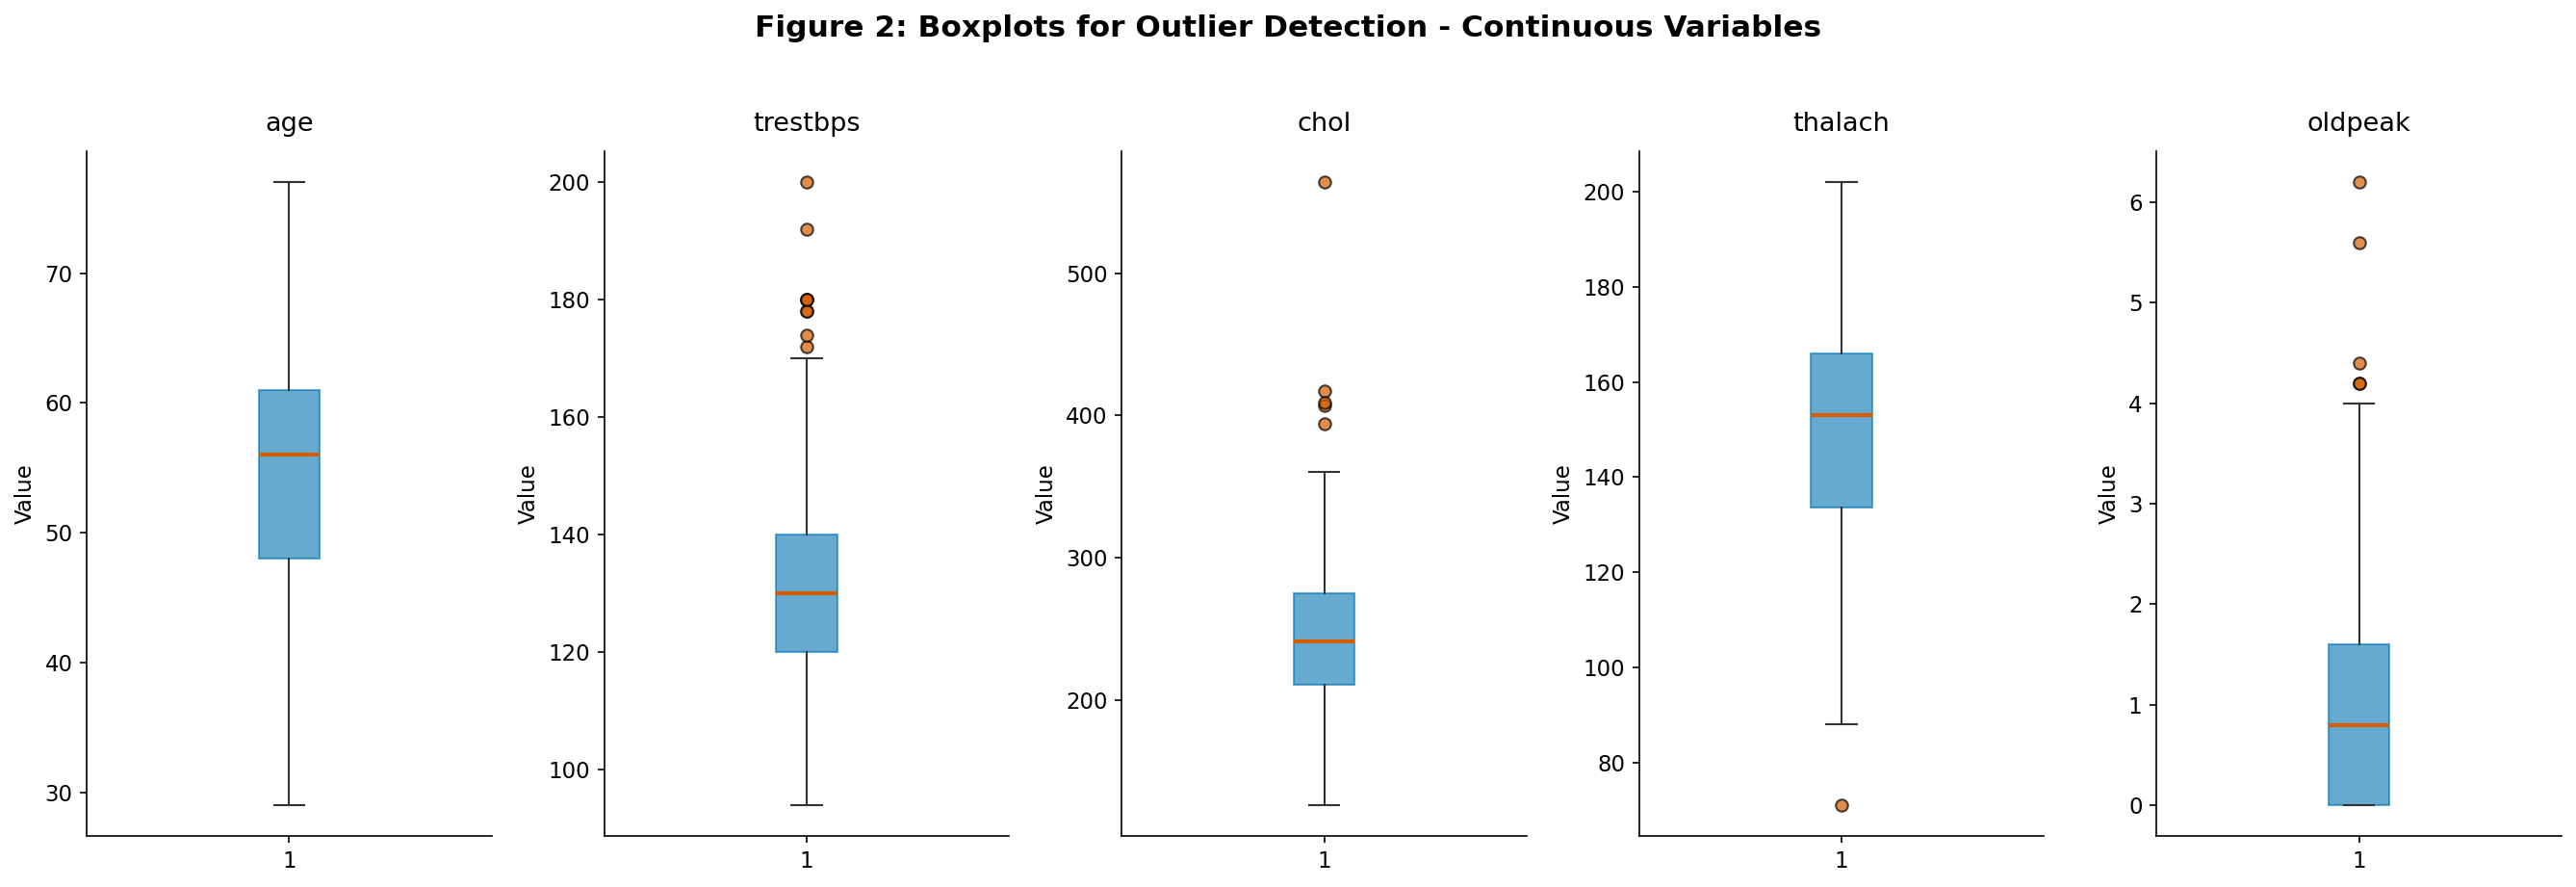

Figure 2 saved


In [11]:
# Boxplots for Outliers

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, col in enumerate(continuous):
    axes[i].boxplot(UCI[col].dropna(),
                    patch_artist=True, # fill box plots with color
                    boxprops=dict(facecolor='#0072B2', # color and style for accessibility and readability
                                  color='#0072B2',
                                  alpha=0.6),
                    medianprops=dict(color='#D55E00',
                                     linewidth=2),
                    whiskerprops=dict(color='#333333'),
                    capprops=dict(color='#333333'),
                    flierprops=dict(marker='o', # outliers
                                    color='#D55E00',
                                    markerfacecolor='#D55E00',
                                    markersize=6,
                                    alpha=0.7))
    axes[i].set_title(f'{col}', fontsize=13, pad=10)
    axes[i].set_ylabel('Value', fontsize=11)

plt.suptitle('Figure 2: Boxplots for Outlier Detection - Continuous Variables',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure2_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 2 saved")

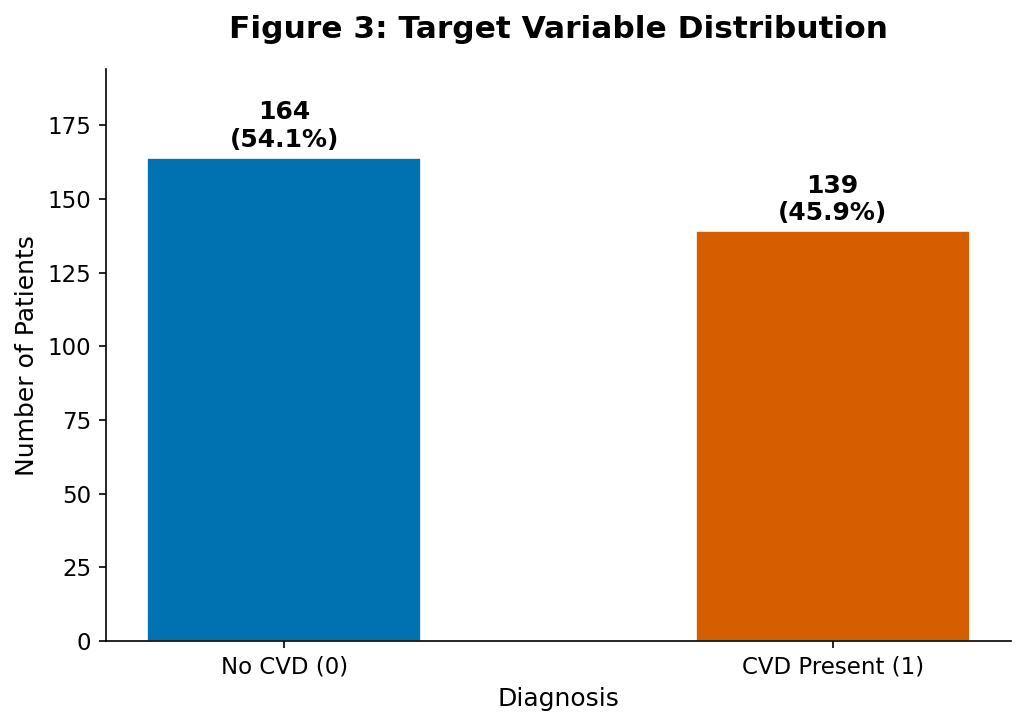

Figure 3 saved


In [12]:
# Target Variable Distribution
fig, ax = plt.subplots(figsize=(7, 5))

# Count values
target_counts = UCI['target'].value_counts().sort_index() #count and sort values
target_labels = ['No CVD (0)', 'CVD Present (1)'] # label for readability
colors = ['#0072B2', '#D55E00']

bars = ax.bar(target_labels, target_counts.values, # bar chart creation
              color=colors, edgecolor='white',
              linewidth=0.8, width=0.5)

# Add count and percentage labels on top of each bar
total = len(UCI)
for bar, count in zip(bars, target_counts.values): # zip to pair each bar with corresponding count to loop through both at the same time
    percentage = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, # set label label center for appearance and neatness
            bar.get_height() + 2, # place label above bar with padding
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', # text at center of bar, bottom of text above bar
            fontsize=12, fontweight='bold')

ax.set_title('Figure 3: Target Variable Distribution',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Diagnosis', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_ylim(0, max(target_counts.values) + 30) # set y axis limit with padding, no label cutoff

plt.tight_layout()
plt.savefig('figure3_target_distribution.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 3 saved")

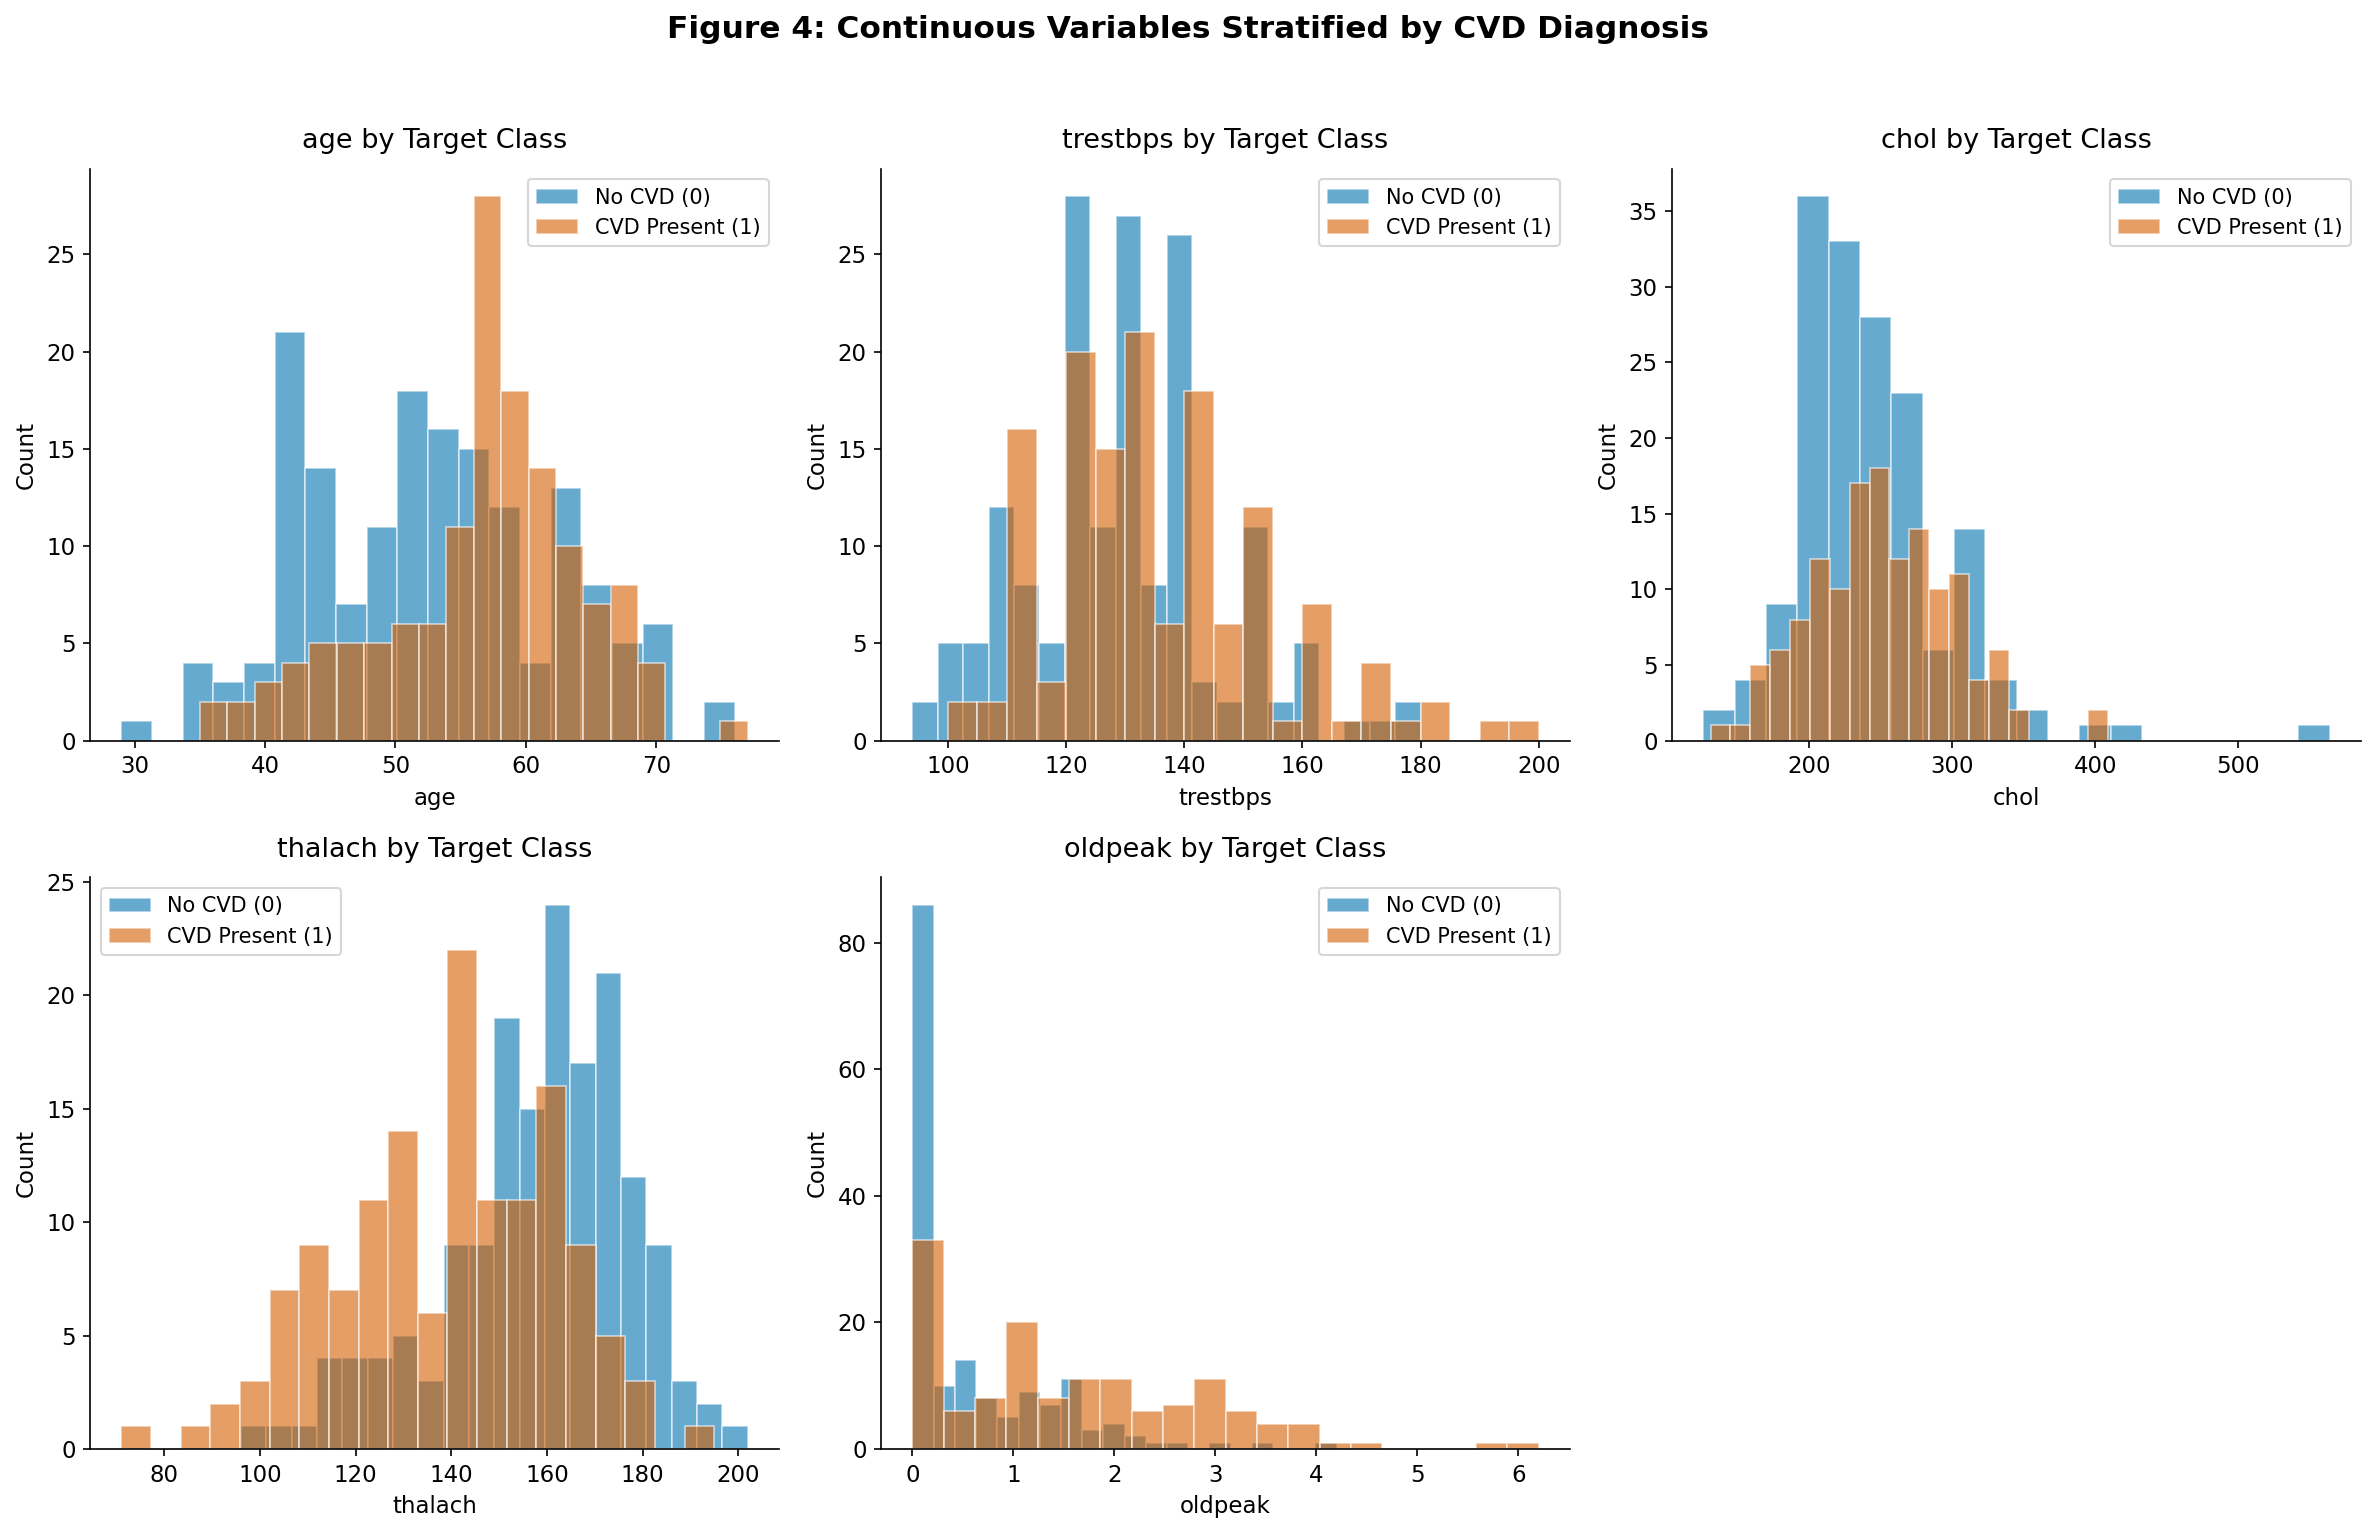

Figure 4 saved


In [13]:
# Continous Variables by Target Class
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(continuous):
    # Plot distribution for each target class
    no_cvd = UCI[UCI['target'] == 0][col].dropna()
    cvd = UCI[UCI['target'] == 1][col].dropna()

    axes[i].hist(no_cvd, bins=20, alpha=0.6, # plot both histograms on same chat with transparency
                 color='#0072B2', edgecolor='white',
                 linewidth=0.8, label='No CVD (0)')
    axes[i].hist(cvd, bins=20, alpha=0.6,
                 color='#D55E00', edgecolor='white',
                 linewidth=0.8, label='CVD Present (1)')

    axes[i].set_title(f'{col} by Target Class',
                      fontsize=13, pad=10)
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Count', fontsize=11)
    axes[i].legend(fontsize=10)

# Hide unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Figure 4: Continuous Variables Stratified by CVD Diagnosis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure4_continuous_by_target.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 4 saved")


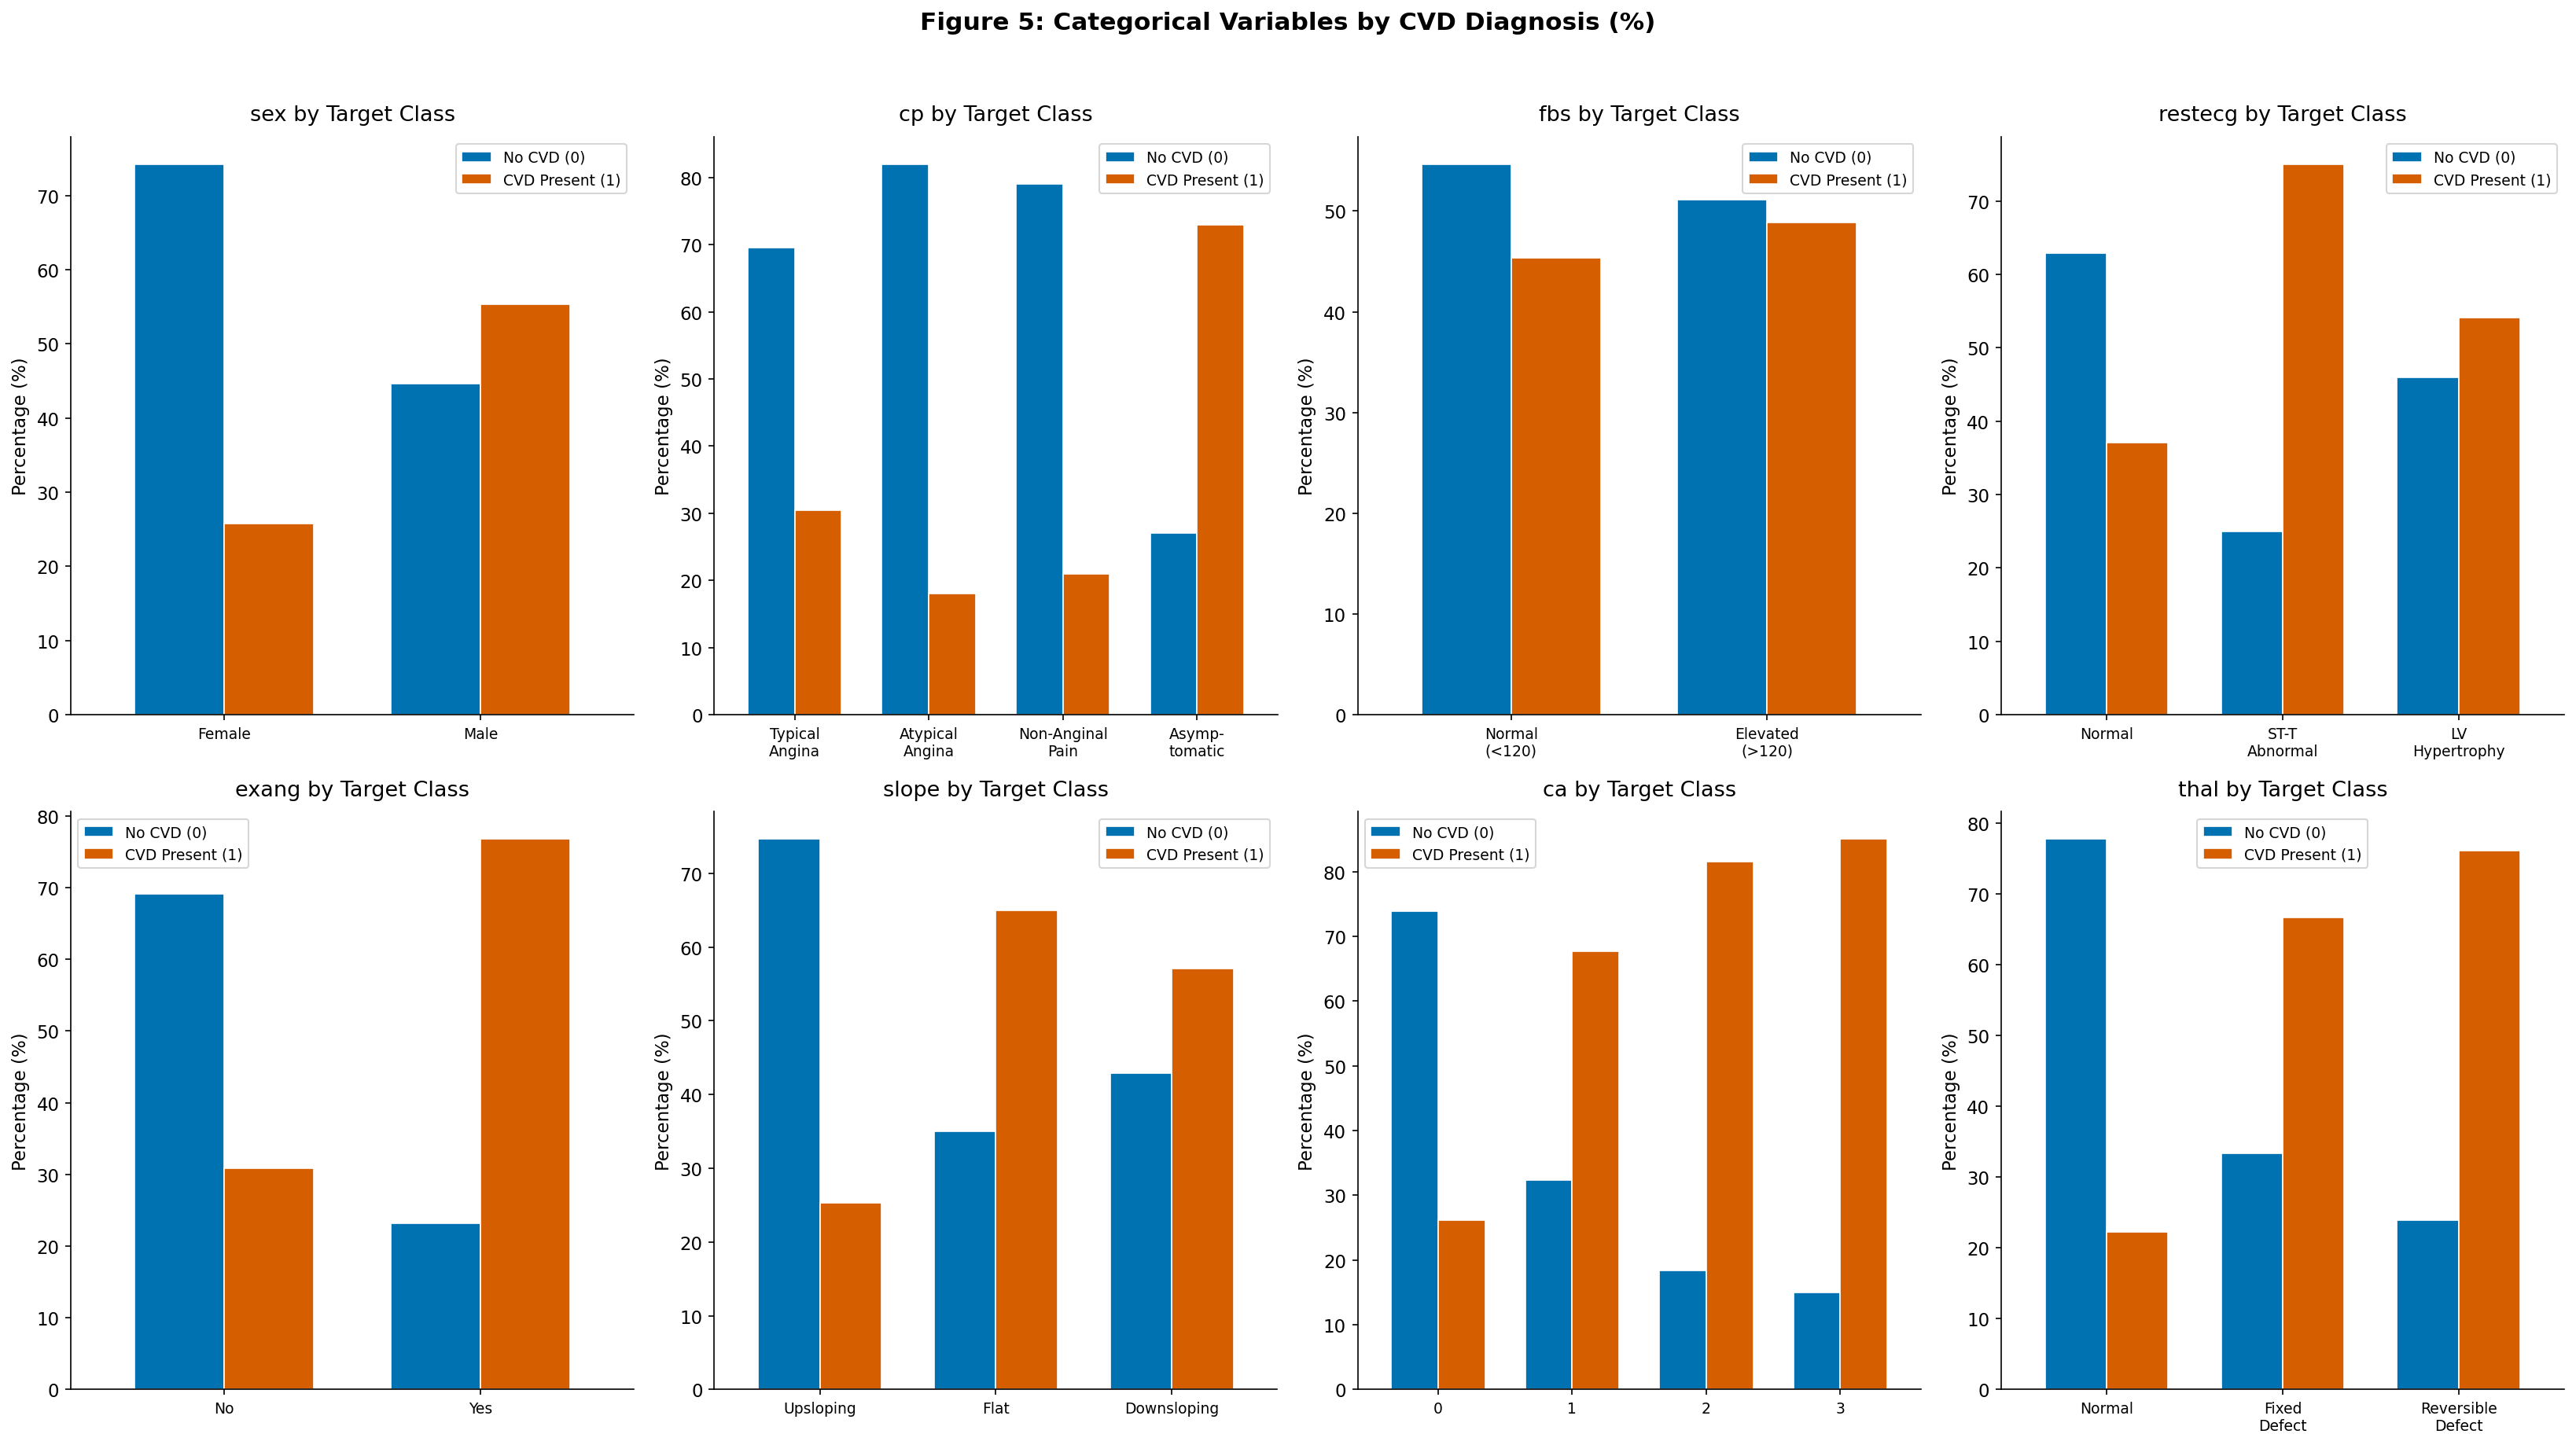

Figure 5 saved


In [14]:
# Continous Variables by Target Class

cat_predictors = [col for col in categorical if col != 'target']

# Labels for each categorical variable
label_maps = { # outer dictionary using column names as keys, inner dictionary using readable label code
    'sex':     {0: 'Female', 1: 'Male'},
    'cp':      {1: 'Typical\nAngina', 2: 'Atypical\nAngina',
                3: 'Non-Anginal\nPain', 4: 'Asymp-\ntomatic'},
    'fbs':     {0: 'Normal\n(<120)', 1: 'Elevated\n(>120)'},
    'restecg': {0: 'Normal', 1: 'ST-T\nAbnormal',
                2: 'LV\nHypertrophy'},
    'exang':   {0: 'No', 1: 'Yes'},
    'slope':   {1: 'Upsloping', 2: 'Flat', 3: 'Downsloping'},
    'ca':      {0.0: '0', 1.0: '1', 2.0: '2', 3.0: '3'},
    'thal':    {3.0: 'Normal', 6.0: 'Fixed\nDefect',
                7.0: 'Reversible\nDefect'}
}

fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(cat_predictors): # create frequency table of relation to each other
    cross_tab = pd.crosstab(UCI[col], UCI['target'], # rows, columns
                            normalize='index') * 100 # convert raw counts to proportions and percentage

    cross_tab.plot(kind='bar', # plot frequency table to bar chart
                   ax=axes[i],
                   color=['#0072B2', '#D55E00'],
                   edgecolor='white',
                   linewidth=0.8,
                   width=0.7)

    # Apply labels
    # go thorugh every axis label for a column, figure out what number it represents, look up the readbale format from label_maps, and replace with that label name
    if col in label_maps:
        current_labels = [label_maps[col].get(float(t.get_text())
                         if '.' in t.get_text() # if text contains decimal, convert to float, otherwise integer
                         else int(t.get_text()),
                         t.get_text()) # keep original text if number map not found
                         for t in axes[i].get_xticklabels()] # loop through current axis ticks, gets current labels as currently appear on plot
        axes[i].set_xticklabels(current_labels, fontsize=9) # replace with readable format

    axes[i].set_title(f'{col} by Target Class',
                      fontsize=13, pad=10)
    axes[i].set_xlabel('', fontsize=11)
    axes[i].set_ylabel('Percentage (%)', fontsize=11)
    axes[i].legend(['No CVD (0)', 'CVD Present (1)'],
                   fontsize=9)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Figure 5: Categorical Variables by CVD Diagnosis (%)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure5_categorical_by_target.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 5 saved")



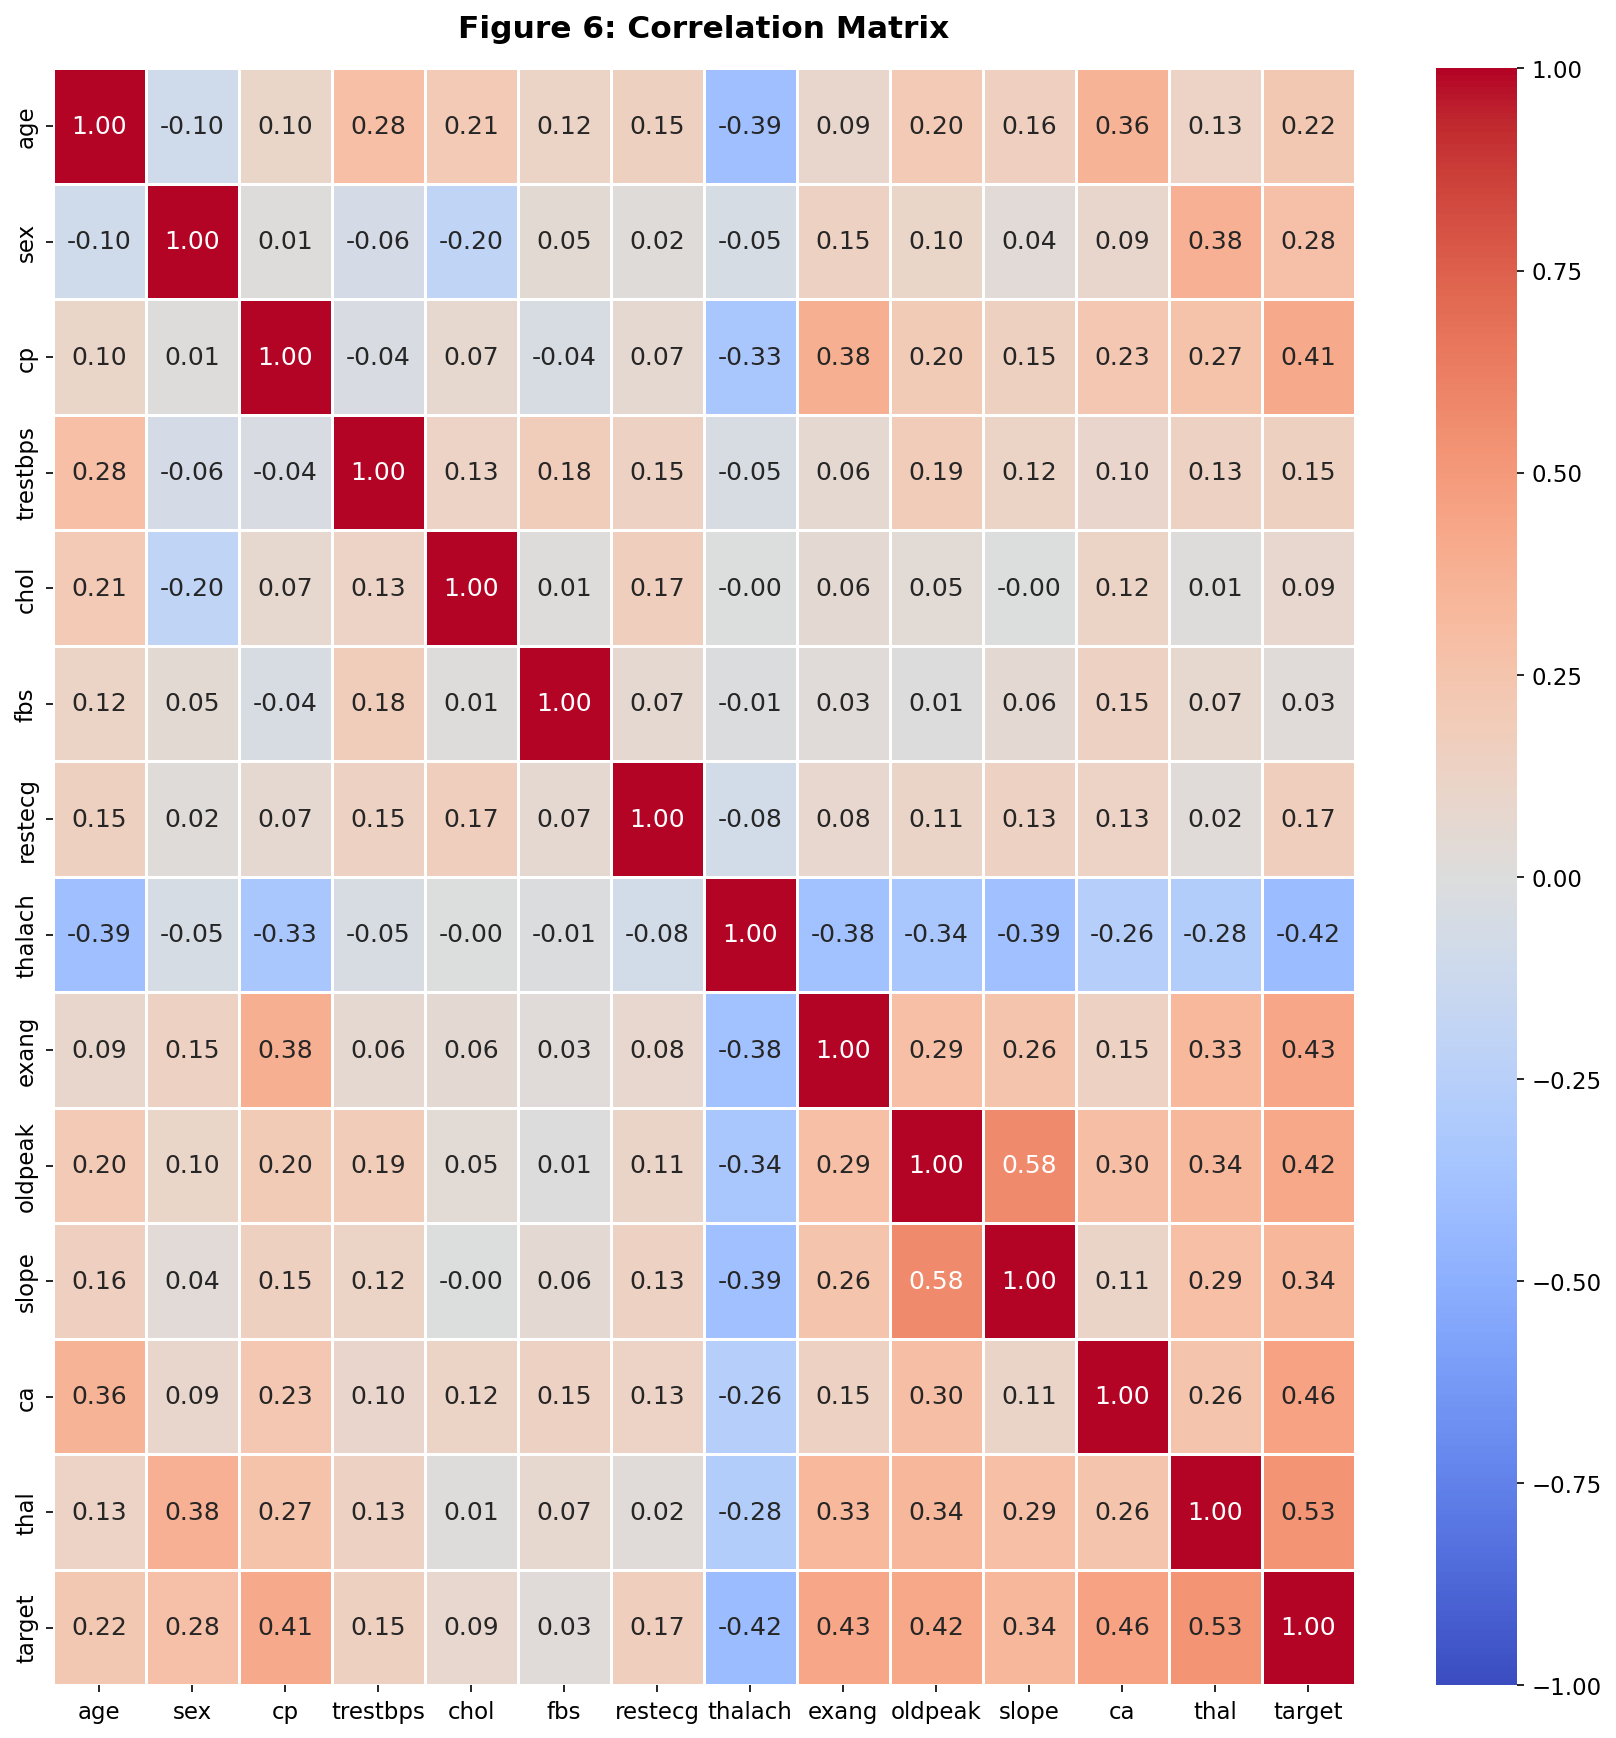

Figure 6 saved


In [15]:
# Correlation Matrix and Heatmap

corr_matrix = UCI.select_dtypes(include = 'number').corr() # calculate correlation matrix

fig, ax = plt.subplots(figsize=(14, 14))

# Plot Heatmap
sns.heatmap(corr_matrix, annot=True, fmt ='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, ax=ax)

ax.set_title('Figure 6: Correlation Matrix',
              fontsize=15, fontweight='bold', pad=15)

plt.savefig('figure6_correlation_matrix.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 6 saved")

In [16]:
# Tables for Continuous Variables

!pip install dataframe_image
import dataframe_image as dfi

table1 = cont_stats[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis']]
table1 = table1.round(2)

table1.columns = ['Mean', 'SD', 'Min', 'Max', 'Skewness', 'Kurtosis'] # improve readability

# Save
dfi.export(table1, 'table1_continuous_stats.png', table_conversion='matplotlib')

print(table1)
print("Table 1 saved")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 MB 18.0 MB/s eta 0:00:00
            Mean     SD    Min    Max  Skewness  Kurtosis
age        54.44   9.04   29.0   77.0     -0.21     -0.52
trestbps  131.69  17.60   94.0  200.0      0.71      0.88
chol      246.69  51.78  126.0  564.0      1.14      4.49
thalach   149.61  22.88   71.0  202.0     -0.54     -0.05
oldpeak     1.04   1.16    0.0    6.2      1.27      1.58
Table 1 saved


In [17]:
# Table for Categorical Variable

# Frequency table for all categorical predictors
cat_predictors = [col for col in categorical if col != 'target']

table2_rows = []

for col in cat_predictors:
    counts = UCI[col].value_counts(dropna=False).sort_index()
    props = UCI[col].value_counts(dropna=False,
                  normalize=True).sort_index().round(3)

    for val in counts.index:
        table2_rows.append({
            'Variable': col,
            'Category': val,
            'Count': counts[val],
            'Proportion': props[val]
        })

table2 = pd.DataFrame(table2_rows) # convert list to dataframe
table2['Proportion'] = table2['Proportion'].round(3) # round to 3 decimal places

# Save as image
dfi.export(table2, 'table2_categorical_stats.png',
           table_conversion='matplotlib')
print(table2)
print("Table 2 saved")


   Variable  Category  Count  Proportion
0       sex       0.0     97       0.320
1       sex       1.0    206       0.680
2        cp       1.0     23       0.076
3        cp       2.0     50       0.165
4        cp       3.0     86       0.284
5        cp       4.0    144       0.475
6       fbs       0.0    258       0.851
7       fbs       1.0     45       0.149
8   restecg       0.0    151       0.498
9   restecg       1.0      4       0.013
10  restecg       2.0    148       0.488
11    exang       0.0    204       0.673
12    exang       1.0     99       0.327
13    slope       1.0    142       0.469
14    slope       2.0    140       0.462
15    slope       3.0     21       0.069
16       ca       0.0    176       0.581
17       ca       1.0     65       0.215
18       ca       2.0     38       0.125
19       ca       3.0     20       0.066
20       ca       NaN      4       0.013
21     thal       3.0    166       0.548
22     thal       6.0     18       0.059
23     thal     

Data Dictionary

In [18]:
# Data Dictionary

# Create Dataframe for data dictionary
data_dict = pd.DataFrame([
    ['age', 'Continuous', 'Age of patient in years', '29 - 77'],
    ['sex', 'Categorical', 'Biological sex', '0 = Female, 1 = Male'],
    ['cp', 'Categorical', 'Chest pain type', '1 = Typical Angina, 2 = Atypical Angina, 3 = Non-Anginal Pain, 4 = Asymptomatic'],
    ['trestbps', 'Continuous', 'Resting blood pressure on admission (mmHg)', '94 - 200'],
    ['chol', 'Continuous', 'Serum cholesterol (mg/dl)', '126 - 564'],
    ['fbs', 'Categorical', 'Fasting blood sugar > 120 mg/dl', '0 = Normal, 1 = Elevated'],
    ['restecg', 'Categorical', 'Resting electrocardiographic results', '0 = Normal, 1 = ST-T Abnormality, 2 = LV Hypertrophy'],
    ['thalach', 'Continuous', 'Maximum heart rate achieved during exercise (bpm)', '71 - 202'],
    ['exang', 'Categorical', 'Exercise induced angina', '0 = No, 1 = Yes'],
    ['oldpeak', 'Continuous', 'ST depression induced by exercise relative to rest', '0.0 - 6.2'],
    ['slope', 'Categorical', 'Slope of peak exercise ST segment', '1 = Upsloping, 2 = Flat, 3 = Downsloping'],
    ['ca', 'Categorical', 'Number of major vessels colored by fluoroscopy', '0 - 3, NaN = Missing'],
    ['thal', 'Categorical', 'Thalassemia type', '3 = Normal, 6 = Fixed Defect, 7 = Reversible Defect, NaN = Missing'],
    ['target', 'Binary Target', 'Cardiovascular disease diagnosis', '0 = No CVD, 1 = CVD Present']
],
columns=['Variable', 'Type', 'Description', 'Values/Range'])

# Make Values/Range column wrap
pd.set_option('display.max_colwidth', None)

# Hide the index and set column widths
dfi.export(data_dict.style.hide(axis='index'),
           'data_dictionary.png',
           table_conversion='matplotlib',
           max_rows=-1,
           max_cols=-1)
print("Data dictionary saved")

Data dictionary saved


Save noteboook

In [19]:
# Save cleaned EDA dataset
# Note: For local use, uncomment the line below and update path a needed
# UCI.to_csv('/content/drive/MyDrive/capstone_cvd_eda.csv', index=False)

# Dataset is available in the /data folder of the GitHub repository
# https://raw.githubusercontent.com/mnooney/CVD_Capstone/main/data/capstone_cvd_eda.csv
print("Dataset available in GitHub /data folder")

Dataset available in GitHub /data folder
